# TT-22 — MLP Regressor: 


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings

RANDOM_STATE = 42
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models', exist_ok=True)


## 1. Đọc và làm sạch dữ liệu


In [2]:
COLUMN_NAMES = ['mpg','cylinders','displacement','horsepower','weight',
                'acceleration','model_year','origin','car_name']

DATA_PATH = '../dataset/auto-mpg.data'

df = pd.read_csv(DATA_PATH, sep=r'\s+', names=COLUMN_NAMES, na_values='?', quotechar='"')
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# Xu ly '?' o horsepower
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
print('So gia tri thieu:', df['horsepower'].isna().sum())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Bo car_name
if 'car_name' in df.columns:
    df = df.drop(columns=['car_name'])

# One-hot origin
df['origin'] = df['origin'].astype(int)
df = pd.get_dummies(df, columns=['origin'], prefix='origin')

print(df.shape)
df.head()


So gia tri thieu: 6
(398, 10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,True,False,False


## 2. EDA 

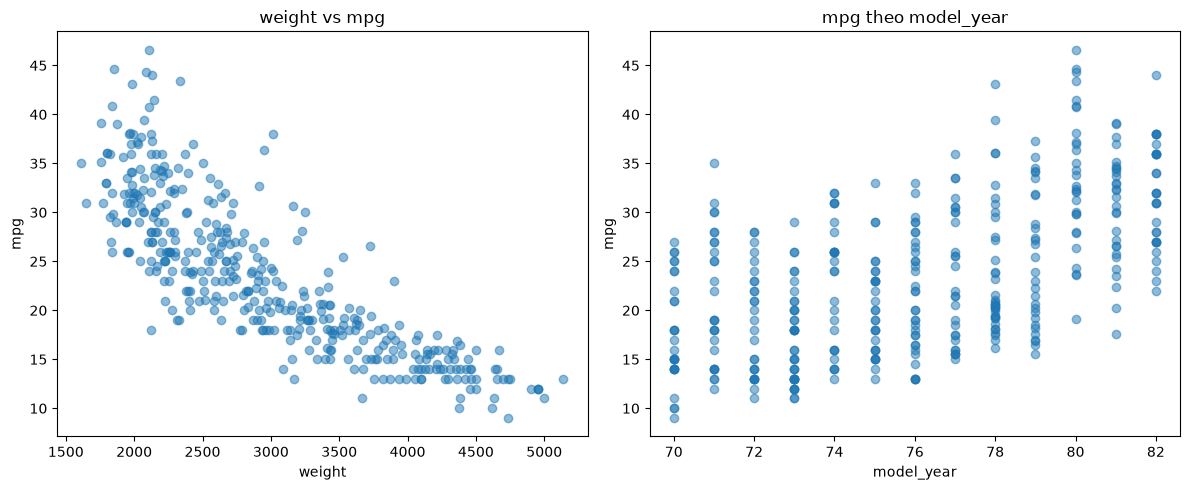

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['weight'], df['mpg'], alpha=0.5)
axes[0].set_xlabel('weight'); axes[0].set_ylabel('mpg')
axes[0].set_title('weight vs mpg')

axes[1].scatter(df['model_year'], df['mpg'], alpha=0.5)
axes[1].set_xlabel('model_year'); axes[1].set_ylabel('mpg')
axes[1].set_title('mpg theo model_year')
plt.tight_layout()
plt.savefig('../reports/eda.png', dpi=120)
plt.show()


## 3. Chia train/test va Baseline (Dummy, Linear, RandomForest, SVR)


In [5]:
X = df.drop(columns=['mpg'])
y = df['mpg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

def eval_model(name, model, results):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    rmse_train = mean_squared_error(y_train, model.predict(X_train)) ** 0.5
    rmse_test = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
    r2_test = r2_score(y_test, model.predict(X_test))
    results.append({'model': name, 'rmse_train': round(rmse_train,3),
                     'rmse_test': round(rmse_test,3), 'r2_test': round(r2_test,4),
                     'train_time_s': round(train_time,3)})
    print(f'[{name}] RMSE train={rmse_train:.3f} RMSE test={rmse_test:.3f} R2={r2_test:.4f}')
    return model

baseline_results = []
eval_model('DummyRegressor', DummyRegressor(strategy='mean'), baseline_results)
eval_model('LinearRegression', LinearRegression(), baseline_results)
eval_model('RandomForest', RandomForestRegressor(random_state=RANDOM_STATE), baseline_results)
eval_model('SVR', Pipeline([('scale', StandardScaler()), ('svr', SVR())]), baseline_results)

pd.DataFrame(baseline_results)


[DummyRegressor] RMSE train=7.918 RMSE test=7.347 R2=-0.0040
[LinearRegression] RMSE train=3.370 RMSE test=2.888 R2=0.8449
[RandomForest] RMSE train=1.094 RMSE test=2.130 R2=0.9157
[SVR] RMSE train=3.265 RMSE test=2.680 R2=0.8665


,model,rmse_train,rmse_test,r2_test,train_time_s
0,DummyRegressor,7.918,7.347,-0.0040,0.023
1,LinearRegression,3.370,2.888,0.8449,0.002
2,RandomForest,1.094,2.130,0.9157,0.105
3,SVR,3.265,2.680,0.8665,0.005


## 4. MLP — ảnh hưởng của scaling (không scale / chỉ X / X và y)

In [6]:
scale_results = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    mlp_raw = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=2000,
                            early_stopping=True, n_iter_no_change=30, random_state=RANDOM_STATE)
    eval_model('MLP (khong scale)', mlp_raw, scale_results)

    mlp_x = Pipeline([('scale', StandardScaler()),
                       ('mlp', MLPRegressor(hidden_layer_sizes=(64,32), max_iter=2000,
                                             early_stopping=True, n_iter_no_change=30,
                                             random_state=RANDOM_STATE))])
    eval_model('MLP (scale X)', mlp_x, scale_results)

    net = Pipeline([('scale', StandardScaler()),
                     ('mlp', MLPRegressor(hidden_layer_sizes=(64,32), max_iter=2000,
                                           early_stopping=True, n_iter_no_change=30,
                                           random_state=RANDOM_STATE))])
    mlp_xy = TransformedTargetRegressor(regressor=net, transformer=StandardScaler())
    eval_model('MLP (scale X va y)', mlp_xy, scale_results)

scale_df = pd.DataFrame(scale_results)
scale_df.to_csv('../reports/scale_comparison.csv', index=False)
scale_df


[MLP (khong scale)] RMSE train=3.788 RMSE test=3.186 R2=0.8112
[MLP (scale X)] RMSE train=2.519 RMSE test=2.250 R2=0.9058
[MLP (scale X va y)] RMSE train=2.211 RMSE test=2.106 R2=0.9175


,model,rmse_train,rmse_test,r2_test,train_time_s
0,MLP (khong scale),3.788,3.186,0.8112,0.249
1,MLP (scale X),2.519,2.250,0.9058,0.631
2,MLP (scale X va y),2.211,2.106,0.9175,0.194


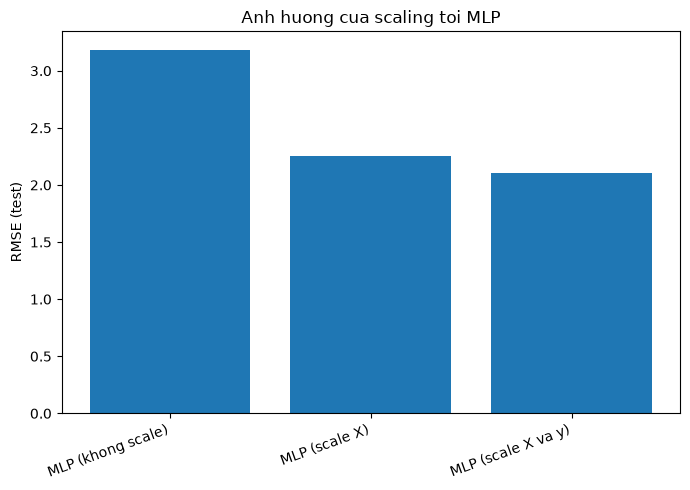

In [7]:
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(scale_df['model'], scale_df['rmse_test'])
ax.set_ylabel('RMSE (test)')
ax.set_title('Anh huong cua scaling toi MLP')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../reports/scale_comparison.png', dpi=120)
plt.show()


## 5. So sánh 4 kiến trúc

In [8]:
architectures = [(16,), (64,), (64,32), (256,128,64)]
arch_results = []

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for arch in architectures:
        net = Pipeline([('scale', StandardScaler()),
                         ('mlp', MLPRegressor(hidden_layer_sizes=arch, max_iter=2000,
                                               early_stopping=True, n_iter_no_change=30,
                                               random_state=RANDOM_STATE))])
        model = TransformedTargetRegressor(regressor=net, transformer=StandardScaler())
        eval_model(f'MLP{arch}', model, arch_results)

        n_features = X_train.shape[1]
        n_params, prev = 0, n_features
        for h in arch:
            n_params += prev*h + h
            prev = h
        n_params += prev*1 + 1
        arch_results[-1]['n_params'] = n_params
        arch_results[-1]['overfit_gap'] = round(arch_results[-1]['rmse_test'] - arch_results[-1]['rmse_train'], 3)

arch_df = pd.DataFrame(arch_results)
arch_df.to_csv('../reports/architecture_comparison.csv', index=False)
arch_df

[MLP(16,)] RMSE train=2.639 RMSE test=2.369 R2=0.8957
[MLP(64,)] RMSE train=2.702 RMSE test=2.322 R2=0.8998
[MLP(64, 32)] RMSE train=2.211 RMSE test=2.106 R2=0.9175
[MLP(256, 128, 64)] RMSE train=2.492 RMSE test=2.223 R2=0.9081


,model,rmse_train,rmse_test,r2_test,train_time_s,n_params,overfit_gap
0,"MLP(16,)",2.639,2.369,0.8957,0.314,177,-0.270
1,"MLP(64,)",2.702,2.322,0.8998,0.133,705,-0.380
2,"MLP(64, 32)",2.211,2.106,0.9175,0.223,2753,-0.105
3,"MLP(256, 128, 64)",2.492,2.223,0.9081,0.295,43777,-0.269


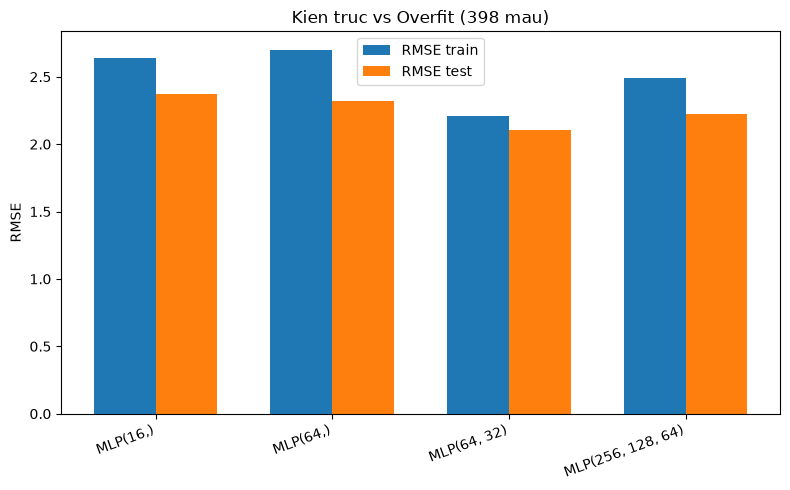

In [9]:
x = np.arange(len(arch_df))
width = 0.35
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, arch_df['rmse_train'], width, label='RMSE train')
ax.bar(x + width/2, arch_df['rmse_test'], width, label='RMSE test')
ax.set_xticks(x); ax.set_xticklabels(arch_df['model'], rotation=20, ha='right')
ax.set_ylabel('RMSE'); ax.set_title('Kien truc vs Overfit (398 mau)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/kien_truc_overfit.png', dpi=120)
plt.show()

## 6. Loss curve của mô hình tốt nhất


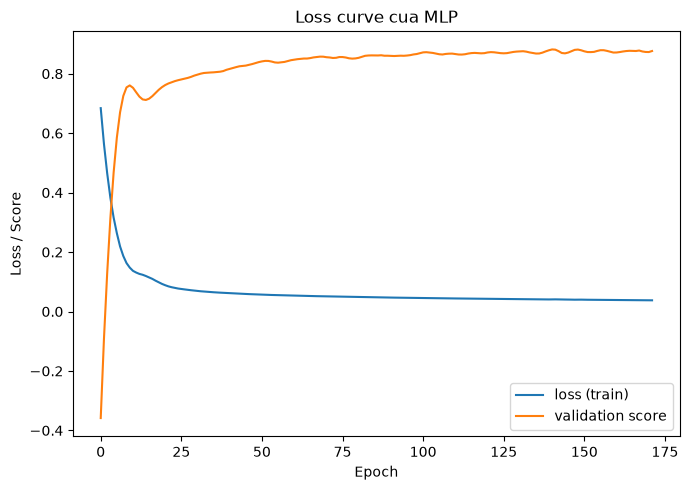

In [10]:
net = Pipeline([('scale', StandardScaler()),
                 ('mlp', MLPRegressor(hidden_layer_sizes=(64,32), alpha=1e-2, max_iter=2000,
                                       early_stopping=True, n_iter_no_change=30,
                                       random_state=RANDOM_STATE))])
best_model = TransformedTargetRegressor(regressor=net, transformer=StandardScaler())
best_model.fit(X_train, y_train)

mlp = best_model.regressor_.named_steps['mlp']
plt.figure(figsize=(7,5))
plt.plot(mlp.loss_curve_, label='loss (train)')
if getattr(mlp, 'validation_scores_', None) is not None:
    plt.plot(mlp.validation_scores_, label='validation score')
plt.xlabel('Epoch'); plt.ylabel('Loss / Score')
plt.title('Loss curve cua MLP')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/loss_curve.png', dpi=120)
plt.show()

## 7. Dò alpha (regularization)


In [11]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1]
alpha_rows = []

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for a in alphas:
        net = Pipeline([('scale', StandardScaler()),
                         ('mlp', MLPRegressor(hidden_layer_sizes=(64,32), alpha=a, max_iter=2000,
                                               early_stopping=True, n_iter_no_change=30,
                                               random_state=RANDOM_STATE))])
        model = TransformedTargetRegressor(regressor=net, transformer=StandardScaler())
        model.fit(X_train, y_train)
        rmse_train = mean_squared_error(y_train, model.predict(X_train)) ** 0.5
        rmse_test = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
        alpha_rows.append({'alpha': a, 'rmse_train': rmse_train, 'rmse_test': rmse_test})

alpha_df = pd.DataFrame(alpha_rows)
alpha_df.to_csv('../reports/alpha_sweep.csv', index=False)
alpha_df


,alpha,rmse_train,rmse_test
0,0.0001,2.211155,2.106402
1,0.0010,2.208497,2.108306
2,0.0100,2.217220,2.104012
3,0.1000,2.245350,2.105226


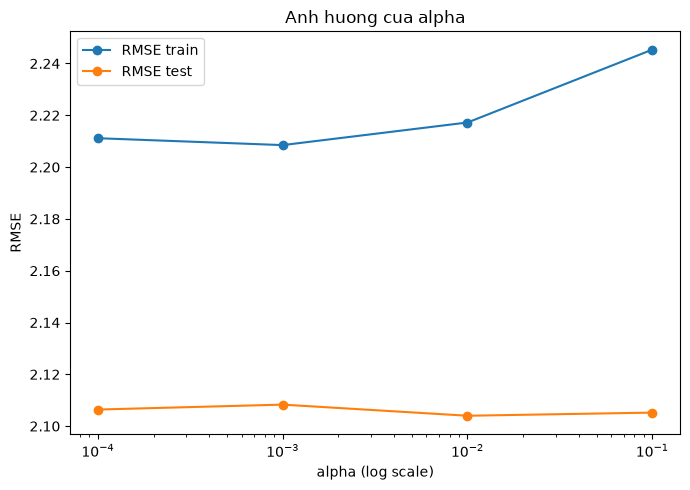

In [12]:
plt.figure(figsize=(7,5))
plt.plot(alpha_df['alpha'], alpha_df['rmse_train'], marker='o', label='RMSE train')
plt.plot(alpha_df['alpha'], alpha_df['rmse_test'], marker='o', label='RMSE test')
plt.xscale('log')
plt.xlabel('alpha (log scale)'); plt.ylabel('RMSE')
plt.title('Anh huong cua alpha')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/alpha_sweep.png', dpi=120)
plt.show()


## 8. So sánh activation: relu / tanh / logistic


In [13]:
activations = ['relu', 'tanh', 'logistic']
act_rows = []

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for act in activations:
        net = Pipeline([('scale', StandardScaler()),
                         ('mlp', MLPRegressor(hidden_layer_sizes=(64,32), activation=act, alpha=1e-2,
                                               max_iter=2000, early_stopping=True, n_iter_no_change=30,
                                               random_state=RANDOM_STATE))])
        model = TransformedTargetRegressor(regressor=net, transformer=StandardScaler())
        model.fit(X_train, y_train)
        rmse_test = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
        r2_test = r2_score(y_test, model.predict(X_test))
        act_rows.append({'activation': act, 'rmse_test': rmse_test, 'r2_test': r2_test})

act_df = pd.DataFrame(act_rows)
act_df.to_csv('../reports/activation_comparison.csv', index=False)
act_df


,activation,rmse_test,r2_test
0,relu,2.104012,0.917665
1,tanh,2.275666,0.903682
2,logistic,3.405299,0.784325


## 9. Bảng so sánh cuối: MLP vs Linear vs RandomForest vs SVR


In [14]:
final_results = baseline_results + [
    {**scale_results[2], 'model': 'MLP (64,32), scale X&y'}
]
final_df = pd.DataFrame(final_results)[['model','rmse_test','r2_test','train_time_s']]
final_df.to_csv('../reports/final_comparison.csv', index=False)
final_df.sort_values('rmse_test')

,model,rmse_test,r2_test,train_time_s
4,"MLP (64,32), scale X&y",2.106,0.9175,0.194
2,RandomForest,2.130,0.9157,0.105
3,SVR,2.680,0.8665,0.005
1,LinearRegression,2.888,0.8449,0.002
0,DummyRegressor,7.347,-0.0040,0.023


## 10. Lưu model


In [15]:
joblib.dump(best_model, '../models/mlp_reg.joblib')
print('Da luu ../models/mlp_reg.joblib')

Da luu ../models/mlp_reg.joblib


## 11. Quy đổi ra L/100km và ước tính tiền xăng/năm

CT: `L/100km = 235.215 / mpg`


In [16]:
def mpg_to_l_per_100km(mpg):
    return 235.215 / mpg

def estimate_yearly_fuel_cost(mpg, km_per_year=15000, price_per_liter_vnd=23000):
    l100 = mpg_to_l_per_100km(mpg)
    liters_per_year = l100 * (km_per_year / 100)
    return l100, liters_per_year * price_per_liter_vnd

sample_pred = best_model.predict(X_test.iloc[:5])
for mpg_val in sample_pred:
    l100, cost = estimate_yearly_fuel_cost(mpg_val)
    print(f'MPG={mpg_val:.1f} -> {l100:.2f} L/100km -> ~{cost:,.0f} VND/nam')


MPG=33.8 -> 6.96 L/100km -> ~24,016,938 VND/nam
MPG=29.9 -> 7.87 L/100km -> ~27,158,522 VND/nam
MPG=18.9 -> 12.44 L/100km -> ~42,931,856 VND/nam
MPG=15.3 -> 15.35 L/100km -> ~52,955,185 VND/nam
MPG=13.8 -> 17.00 L/100km -> ~58,663,436 VND/nam
